# Прогноз открытия срочного депозита по данным банковской маркетинговой кампании

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import StackingClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif
sns.set_palette("pastel")

**Данные о клиентах банка:**

- age (возраст);
- job (сфера занятости);
- marital (семейное положение);
- education (уровень образования);
- default (имеется ли просроченный кредит);
- housing (имеется ли кредит на жильё);
- loan (имеется ли кредит на личные нужды);
- balance (баланс).

**Данные, связанные с последним контактом в контексте текущей маркетинговой кампании:**

- contact (тип контакта с клиентом);
- month (месяц, в котором был последний контакт);
- day (день, в который был последний контакт);
- duration (продолжительность контакта в секундах).

**Прочие признаки:**

- campaign (количество контактов с этим клиентом в течение текущей кампании);
- pdays (количество пропущенных дней с момента последней маркетинговой кампании до контакта в текущей кампании);
- previous (количество контактов до текущей кампании)
- poutcome (результат прошлой маркетинговой кампании).

Целевая переменная **deposit**, которая определяет, согласится ли клиент открыть депозит в банке. Именно её мы будем пытаться предсказать в данном кейсе.

## Часть 1. Обзор данных, пропуски и выбросы

### Загрузка исходных данных и первичный осмотр

In [2]:
from pathlib import Path

DATA_DIR = Path('data') if Path('data').exists() else Path('../data')
DATA_PATH = DATA_DIR / 'bank_fin.csv'
df = pd.read_csv(DATA_PATH, sep=';')
display(df.head(), df.shape)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,"2 343,00 $",yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,"45,00 $",no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,"1 270,00 $",yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,"2 476,00 $",yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,"184,00 $",no,no,unknown,5,may,673,2,-1,0,unknown,yes


(11162, 17)

In [3]:
display(df.info(),
        df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11137 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(6), object(11)
memory usage: 1.4+ MB


None

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### Поиск скрытых пропусков в признаке `job`

In [4]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

### Преобразование `balance` в числовой (float) столбец

In [5]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
df['balance'] = (
    df['balance']
    .str.replace(' ', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.replace('$', '', regex=False)
    .astype(float)
)

### Заполнение пропусков в `balance` медианой

In [6]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
df['balance'] = df['balance'].fillna(df['balance'].median())

### Заполнение пропусков / значений `unknown` в `job` и `education` модой

In [7]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
most_common_job = df['job'].mode()[0]
df['job'] = df['job'].replace('unknown', most_common_job).fillna(most_common_job)

most_common_education = df['education'].mode()[0]
df['education'] = df['education'].replace('unknown', most_common_education).fillna(most_common_education)

### Поиск выбросов в `balance` методом IQR

In [8]:
# удалите все выбросы для признака balance
def outliers_iqr_mod(data, feature, left=1.5, right=1.5, log_scale=False):
    """
    Находит выбросы по методу IQR с возможностью логарифмирования.
    
    Параметры:
    - data: DataFrame с данными.
    - feature: имя столбца для анализа.
    - log_scale: логарифмировать данные (bool).
    - left, right: множители для IQR (границы выбросов).
    
    Возвращает:
    - lower_bound, upper_bound: границы выбросов.
    - outliers: DataFrame с выбросами.
    - cleaned: DataFrame без выбросов.
    """
    
    if log_scale:
        x = np.log(data[feature])
    else:
        x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    
    return lower_bound, upper_bound, outliers, cleaned

lower, upper, outliers, cleaned = outliers_iqr_mod(df, 'balance',)

print(f'Нижняя граница: {round(lower)}')
print(f'Верхняя граница: {round(upper)}')
print(f'Кoл-во выбросов: {outliers.shape[0]}')

Нижняя граница: -2241
Верхняя граница: 4063
Кoл-во выбросов: 1057


Удаление выбросов

In [9]:
df_cleaned = cleaned.copy()
df_cleaned.shape[0]

10105

## Часть 2. Разведочный анализ данных

### Распределения числовых признаков (boxplot и гистограммы)

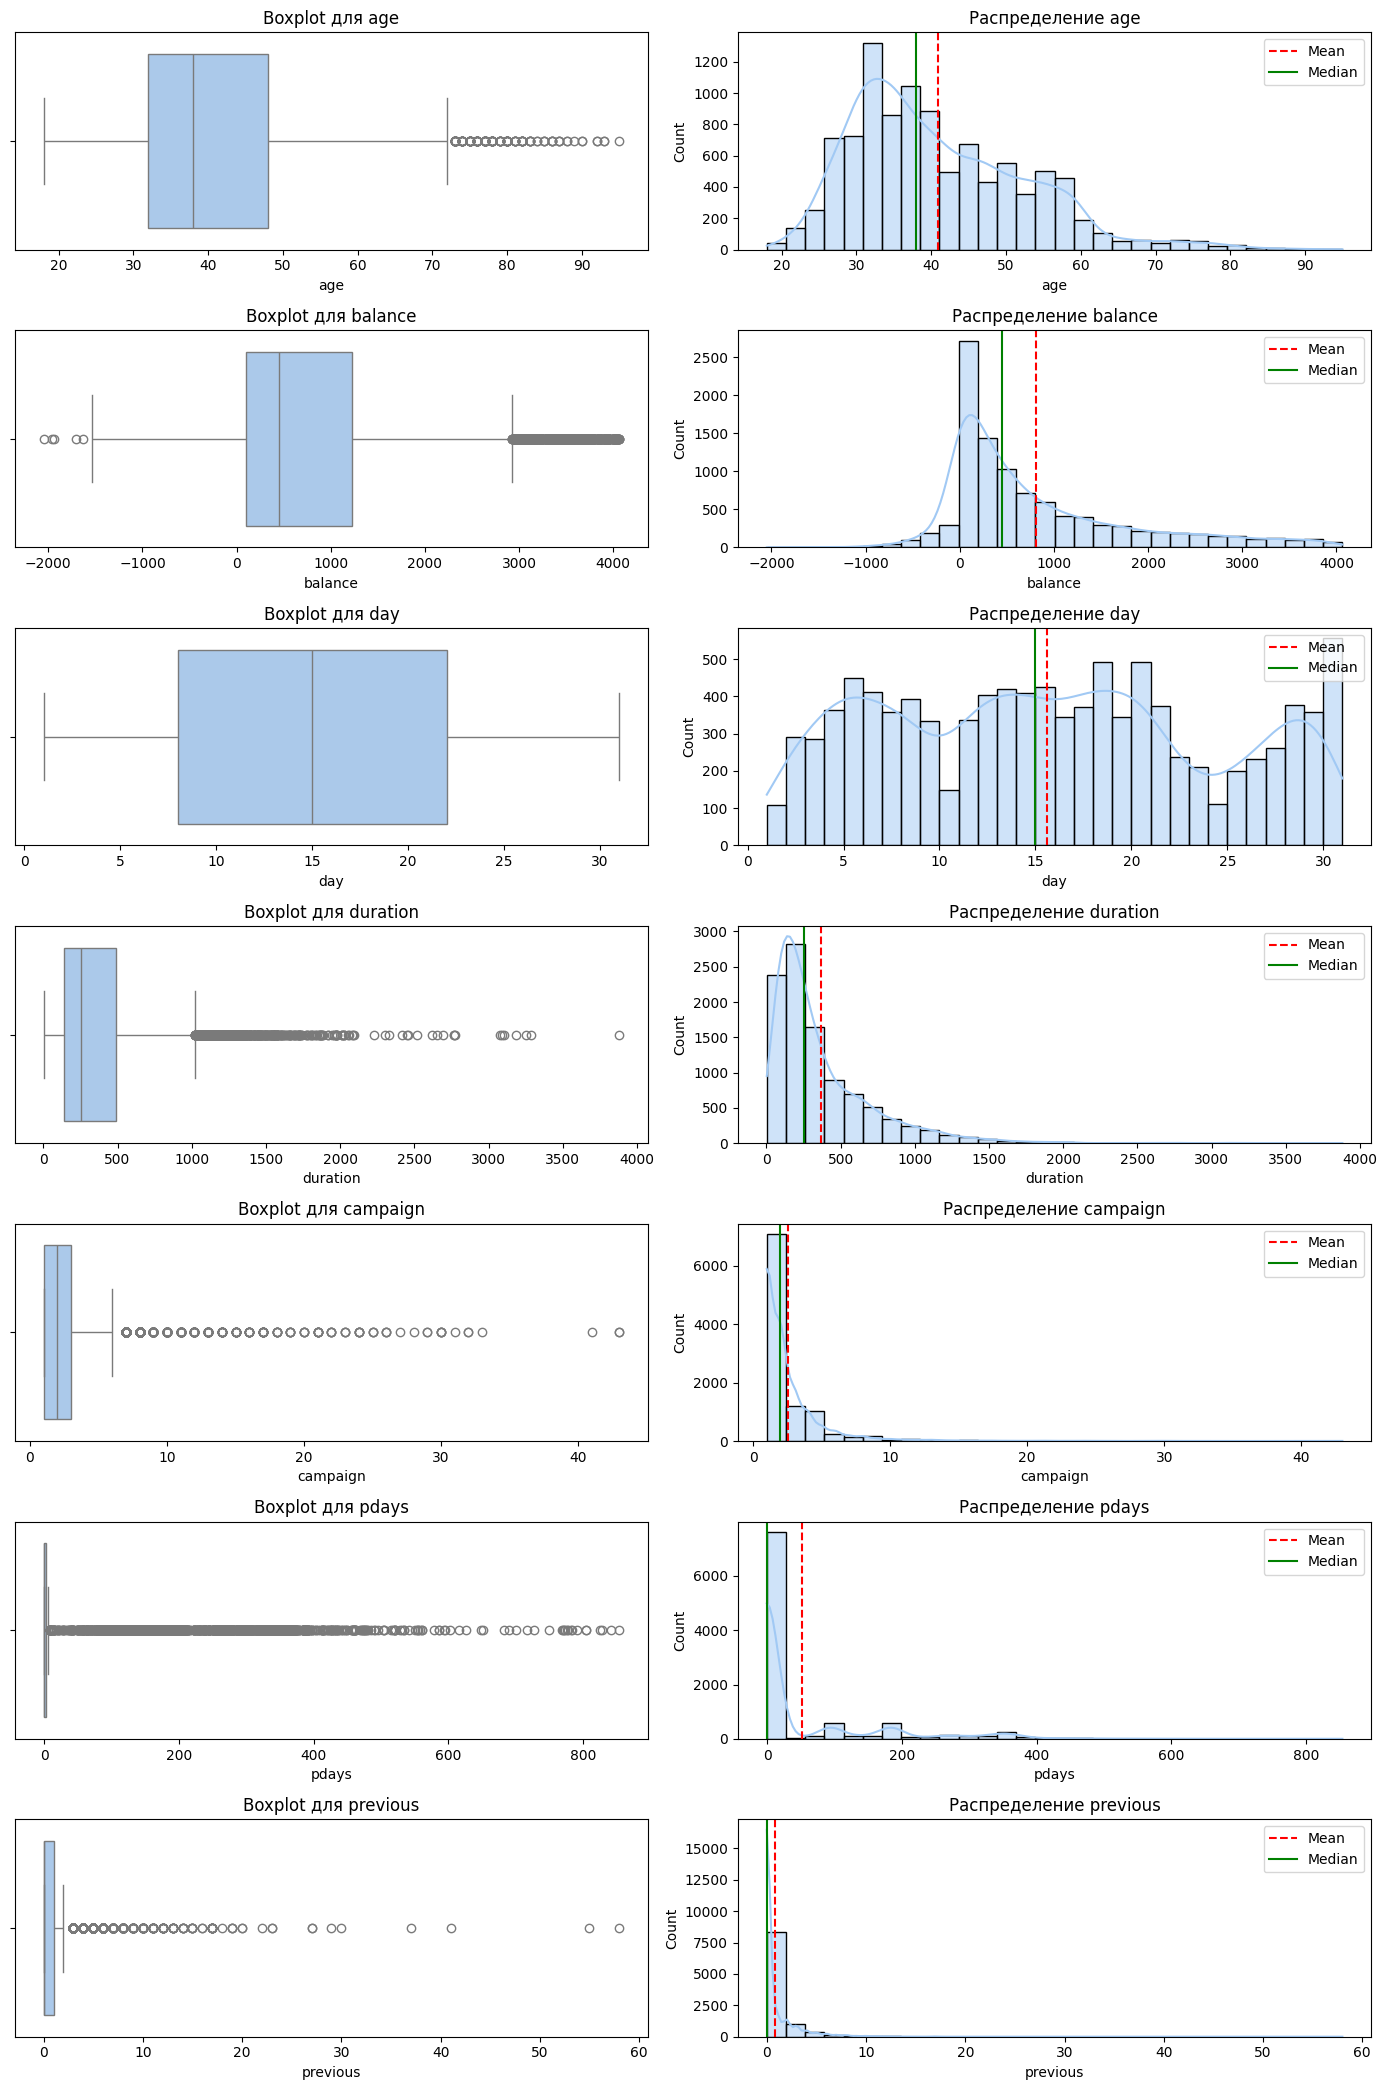

In [10]:
# изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат
quant_features = df_cleaned.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(len(quant_features), 2, figsize=(14, len(quant_features)*3))

for i, feature in enumerate(quant_features):
    sns.boxplot(data=df_cleaned, x=feature, ax=axes[i,0], whis=1.5)
    axes[i,0].set_title(f'Boxplot для {feature}')
    
    sns.histplot(data=df_cleaned, x=feature, ax=axes[i,1], kde=True, bins=30)
    axes[i,1].axvline(df_cleaned[feature].mean(), color='r', linestyle='--', label='Mean')
    axes[i,1].axvline(df_cleaned[feature].median(), color='g', linestyle='-', label='Median')
    axes[i,1].set_title(f'Распределение {feature}')
    axes[i,1].legend()

plt.tight_layout()
plt.show()

**Выводы по графикам:** Распределение длительности контакта(duration), кол-во контактов в течение текущей компании(campaign), pdays и previous имеют правостороннюю асимметрию и жирный хвост, что свидетельствует о наличии данных, значительно превышающих среднее значение(и которые мы будем проверять на предмет выбросов).

### Описательная статистика числовых признаков

In [11]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
df_cleaned[quant_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,10105.0,40.895497,11.734931,18.0,32.0,38.0,48.0,95.0
balance,10105.0,807.653538,994.151966,-2049.0,95.0,445.0,1227.0,4063.0
day,10105.0,15.590302,8.441510,1.0,8.0,15.0,22.0,31.0
duration,10105.0,368.742603,346.651524,2.0,137.0,252.0,490.0,3881.0
campaign,10105.0,2.517170,2.707159,1.0,1.0,2.0,3.0,43.0
pdays,10105.0,51.319644,109.644179,-1.0,-1.0,-1.0,2.0,854.0
previous,10105.0,0.816230,2.243795,0.0,0.0,0.0,1.0,58.0


### Распределение категориальных признаков

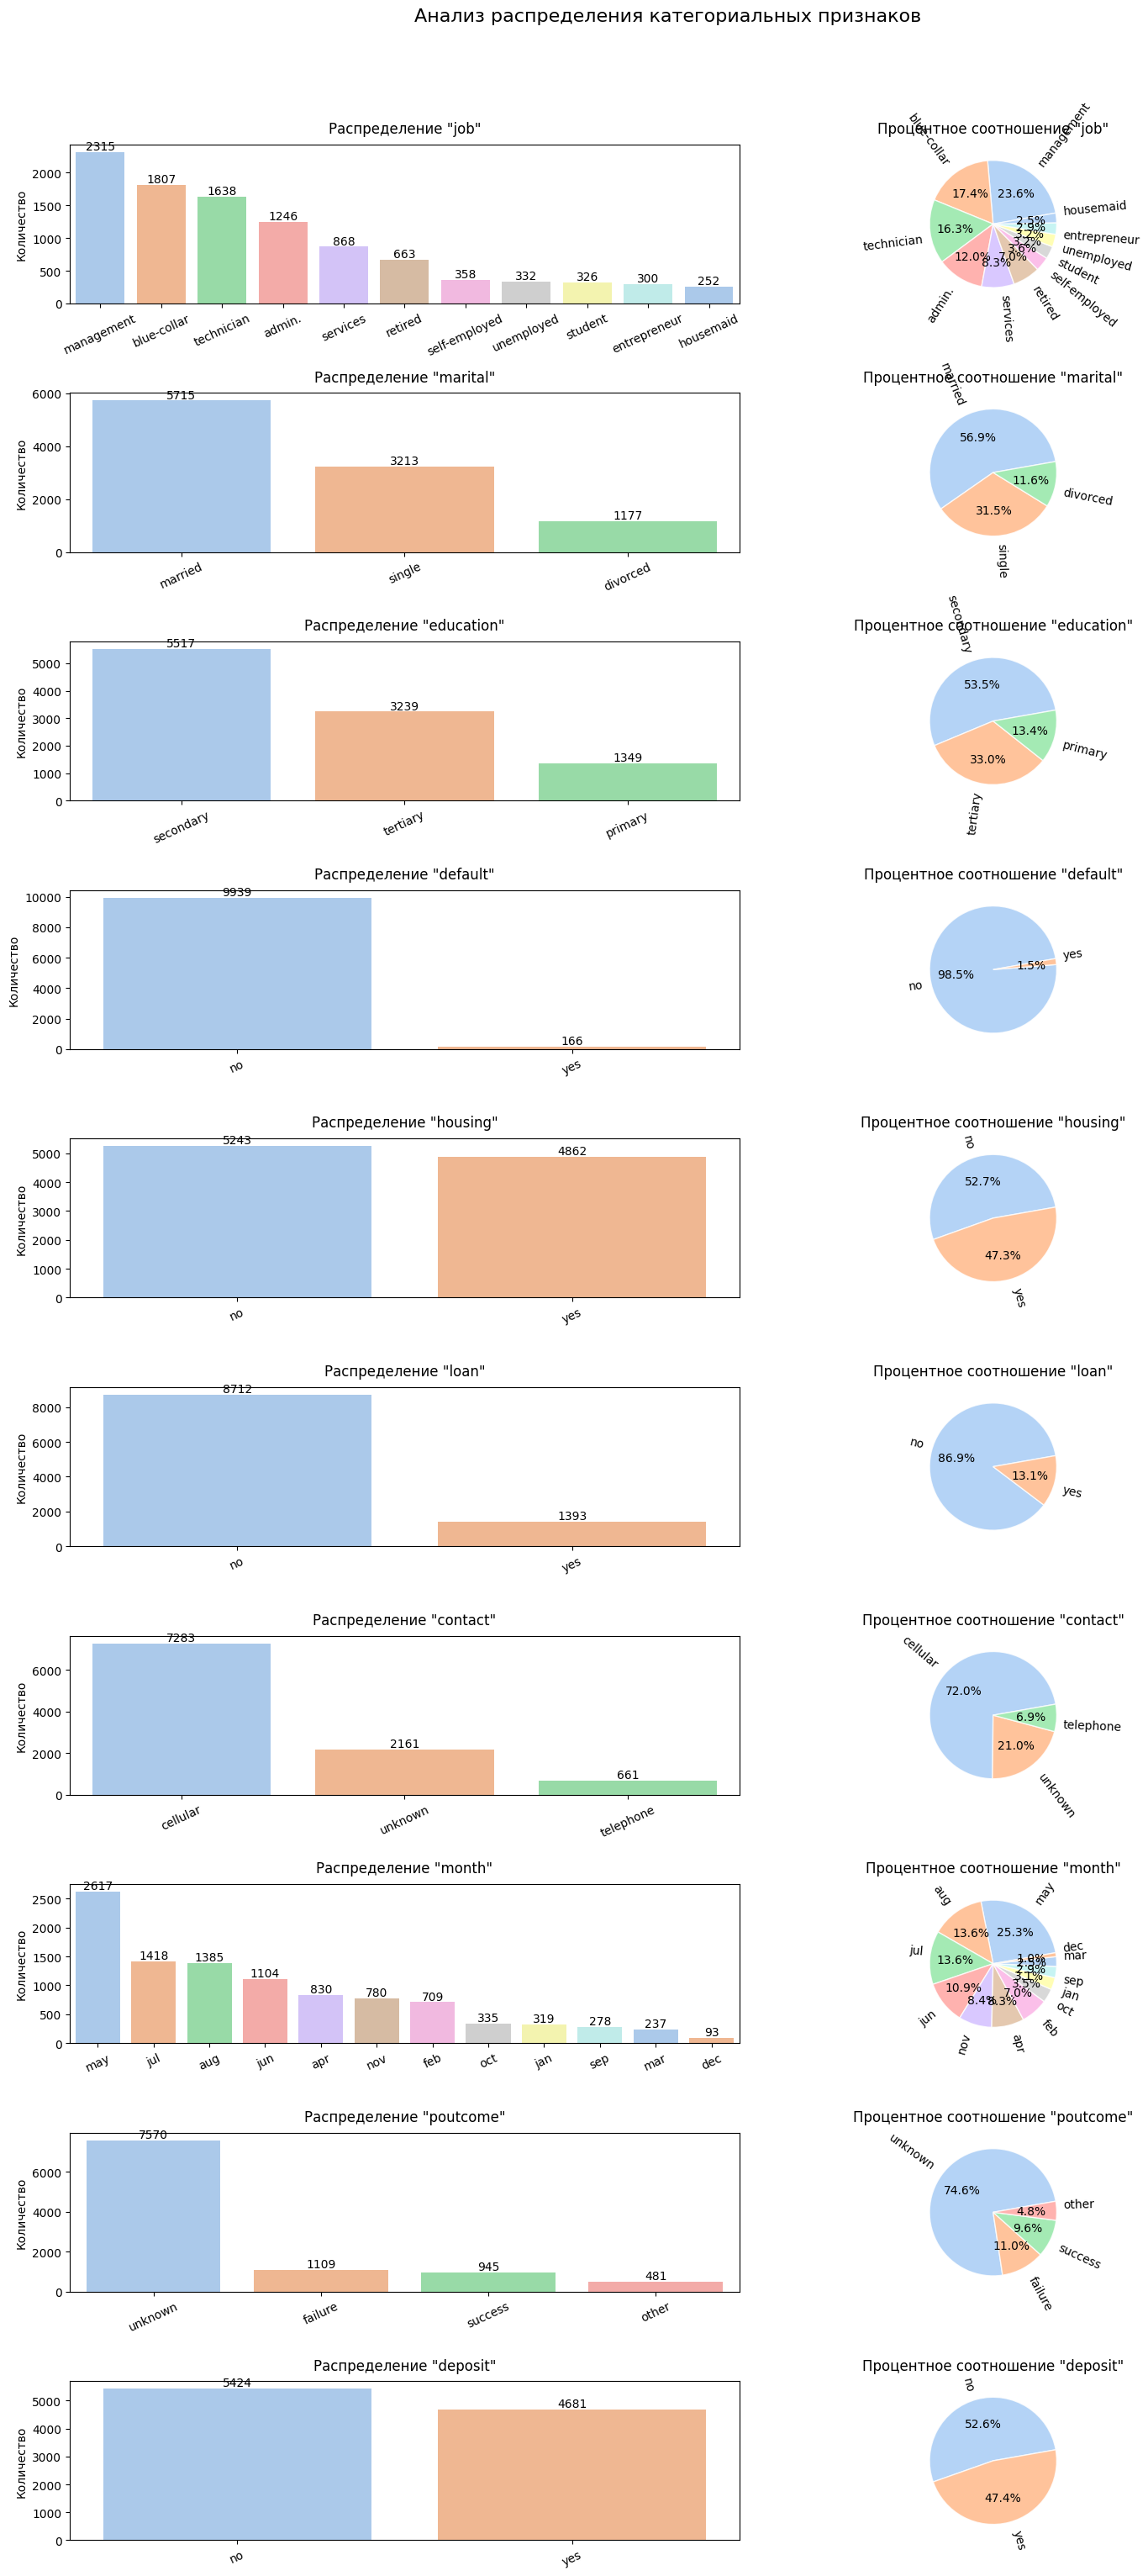

In [12]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
cat_features = df_cleaned.select_dtypes(include=['object', 'category']).columns
n = len(cat_features)

fig, axes = plt.subplots(n, 2, figsize=(16, n*3))
fig.suptitle('Анализ распределения категориальных признаков', y=1.02, fontsize=16)

# Цикл по всем категориальным признакам
for i, feature in enumerate(cat_features):
    ax1 = axes[i, 0]
    countplot = sns.countplot(data=df_cleaned, x=feature, ax=ax1, order=df_cleaned[feature].value_counts().index, palette='pastel')
    countplot.set_title(f'Распределение "{feature}"', pad=10)
    countplot.set_xlabel('')
    countplot.xaxis.set_tick_params(rotation=25)
    countplot.set_ylabel('Количество')
    
    # Добавляем аннотации с количеством
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
    
    # График процентного соотношения
    ax2 = axes[i, 1]
    value_counts = df[feature].value_counts(normalize=True)
    pie = ax2.pie(value_counts, 
                 labels=value_counts.index,
                 autopct='%1.1f%%',
                 startangle=10,
                 textprops={'fontsize': 10},
                 rotatelabels=True)
    ax2.set_title(f'Процентное соотношение "{feature}"', pad=10)
    for w in pie[0]:
        w.set_edgecolor('white')
        w.set_alpha(0.8)
plt.tight_layout()
plt.show()

**Вывод по графику:** Анализ признака month показал выраженную сезонность в откликах клиентов. В частности, в мае наблюдается наибольшее количество отказов: около 2/3 всех контактов заканчиваются ответом “нет”. В то же время в другие месяцы, такие как октябрь, декабрь, март и сентябрь, несмотря на меньший объём данных, доля положительных ответов заметно преобладает над отказами. Это может свидетельствовать о более благоприятном восприятии предложений в эти периоды.

### Результат прошлой кампании (`poutcome`) и доля открытых депозитов

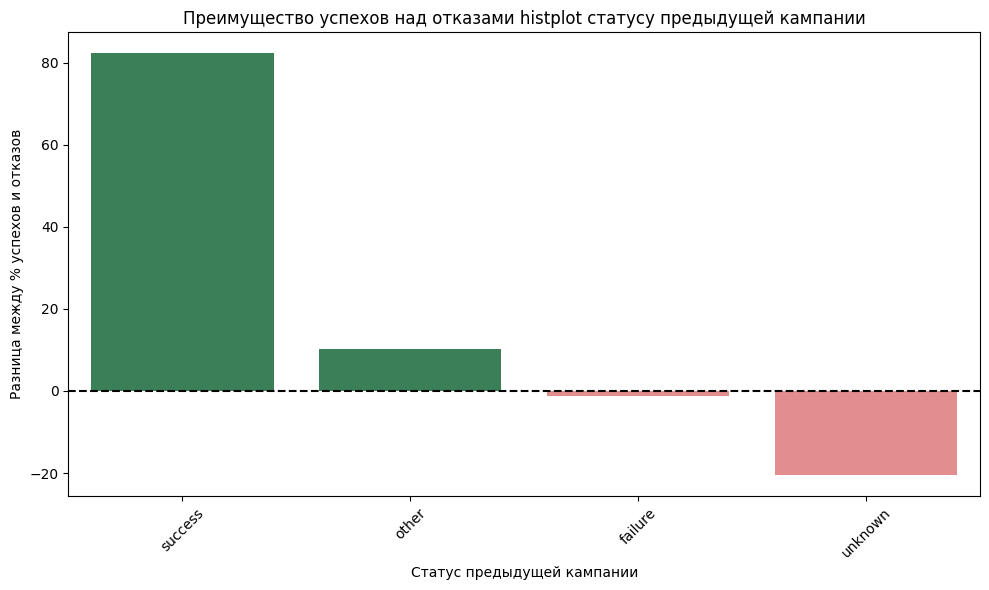

Статус предыдущей кампании, где успехи превалируют над отказами: 'success'

Детальная статистика:
deposit     no   yes  success_advantage
poutcome                               
success    8.9  91.1               82.2
other     44.9  55.1               10.2
failure   50.7  49.3               -1.4
unknown   60.3  39.7              -20.5


In [13]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
poutcome_result = df_cleaned.groupby('poutcome')['deposit'].value_counts(normalize=True).unstack() * 100

# Добавляем столбец с разницей между успехами и отказами
poutcome_result['success_advantage'] = poutcome_result['yes'] - poutcome_result['no']

poutcome_result = poutcome_result.sort_values('success_advantage', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=poutcome_result.index, y=poutcome_result['success_advantage'], 
            palette=['lightcoral' if x < 0 else 'seagreen' for x in poutcome_result['success_advantage']])
plt.axhline(0, color='black', linestyle='--')
plt.title('Преимущество успехов над отказами histplot статусу предыдущей кампании')
plt.ylabel('Разница между % успехов и отказов')
plt.xlabel('Статус предыдущей кампании')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt
# Вывод результата
dominant_status = poutcome_result[poutcome_result['success_advantage'] > 0].index[0]
print(f"Статус предыдущей кампании, где успехи превалируют над отказами: '{dominant_status}'")
print("\nДетальная статистика:")
print(poutcome_result.round(1))

### Сезонность отказов по месяцам

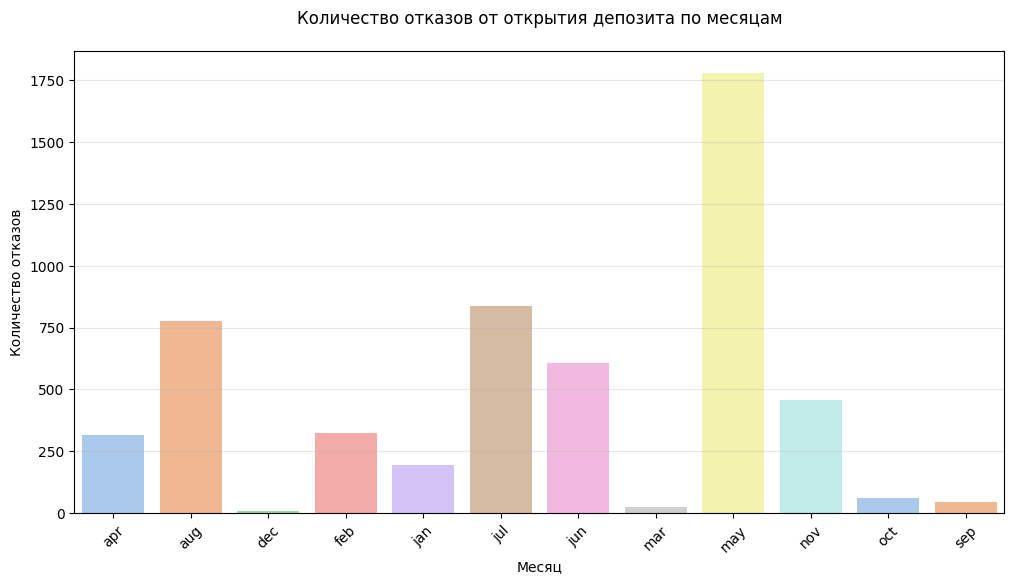


Месяц с наибольшим количеством отказов: may
Количество отказов в этом месяце: 1776

Доля отказов по месяцам (%):
month
apr    38.2
aug    56.0
dec     9.7
feb    45.6
jan    60.8
jul    59.0
jun    54.9
mar    10.1
may    67.9
nov    58.5
oct    18.5
sep    16.5
Name: deposit, dtype: float64


In [14]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
rejections = df_cleaned[df_cleaned['deposit']=='no']
monthly_rejections = rejections['month'].value_counts().sort_index()

monthly_rejection_rate = df_cleaned.groupby('month')['deposit'].apply(
    lambda x: (x == 'no').mean() * 100
).sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_rejections.index, y=monthly_rejections.values, palette='pastel')
plt.title('Количество отказов от открытия депозита по месяцам', pad=20)
plt.xlabel('Месяц')
plt.ylabel('Количество отказов')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

max_month = monthly_rejections.idxmax()
print(f"\nМесяц с наибольшим количеством отказов: {max_month}")
print(f"Количество отказов в этом месяце: {monthly_rejections[max_month]}")
print(f"\nДоля отказов по месяцам (%):\n{monthly_rejection_rate.round(1)}")

**Вывод по графику:** Анализ признака month показал выраженную сезонность в откликах клиентов. В частности, в мае наблюдается наибольшее количество отказов: около 2/3 всех контактов заканчиваются ответом “нет”. В то же время в другие месяцы, такие как октябрь, декабрь, март и сентябрь, несмотря на меньший объём данных, доля положительных ответов заметно преобладает над отказами. Это может свидетельствовать о более благоприятном восприятии предложений в эти периоды.

### Доля открытых депозитов по возрастным группам

deposit      no   yes  yes_ratio
age_group                       
<30         819  1051      56.20
30-40      2215  1627      42.35
40-50      1360   895      39.69
50-60       933   692      42.58
60+          97   416      81.09


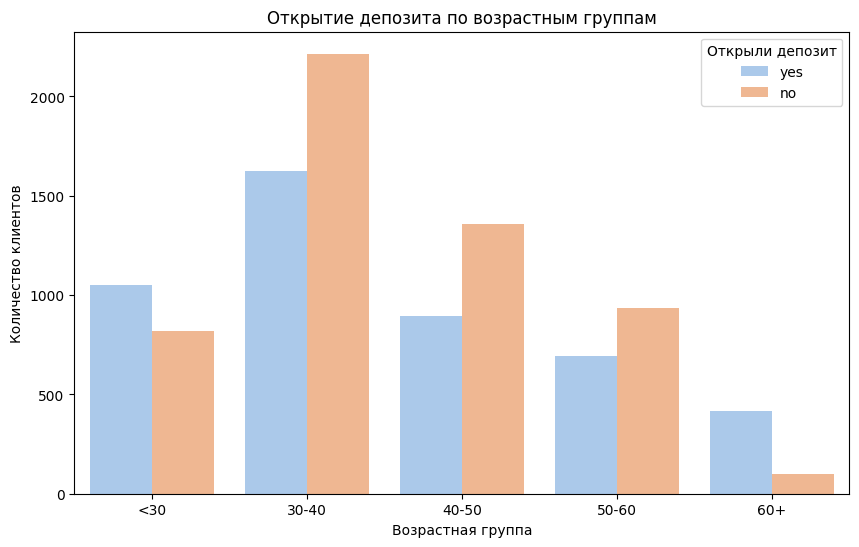

In [15]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
df_cleaned['age_group'] = pd.cut(df_cleaned.age, [0,30,40,50,60,9999], labels=['<30', '30-40', '40-50', '50-60', '60+'])

# Построим сводную табличку с возрастными группами и индикатором депозита
pivot_table_age = pd.crosstab(df_cleaned['age_group'], df_cleaned['deposit'])
# Создадим новый признак процент успеха
pivot_table_age['yes_ratio'] = round(pivot_table_age['yes'] / (pivot_table_age['yes'] + pivot_table_age['no']) * 100, 2)
print(pivot_table_age)

plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned, x='age_group', hue='deposit', palette='pastel')
plt.title('Открытие депозита по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество клиентов')
plt.legend(title='Открыли депозит')

plt.show()

**Вывод по графику:** Наибольший процент открытий депозитов — в возрастной группе 60+ (81%). Далее идет группа <30 лет (59%). Остальные группы (30–40, 40–50, 50–60) имеют заметно меньшие показатели — около 40% каждая.

### Доля открытых депозитов по семейному положению, профессии и образованию

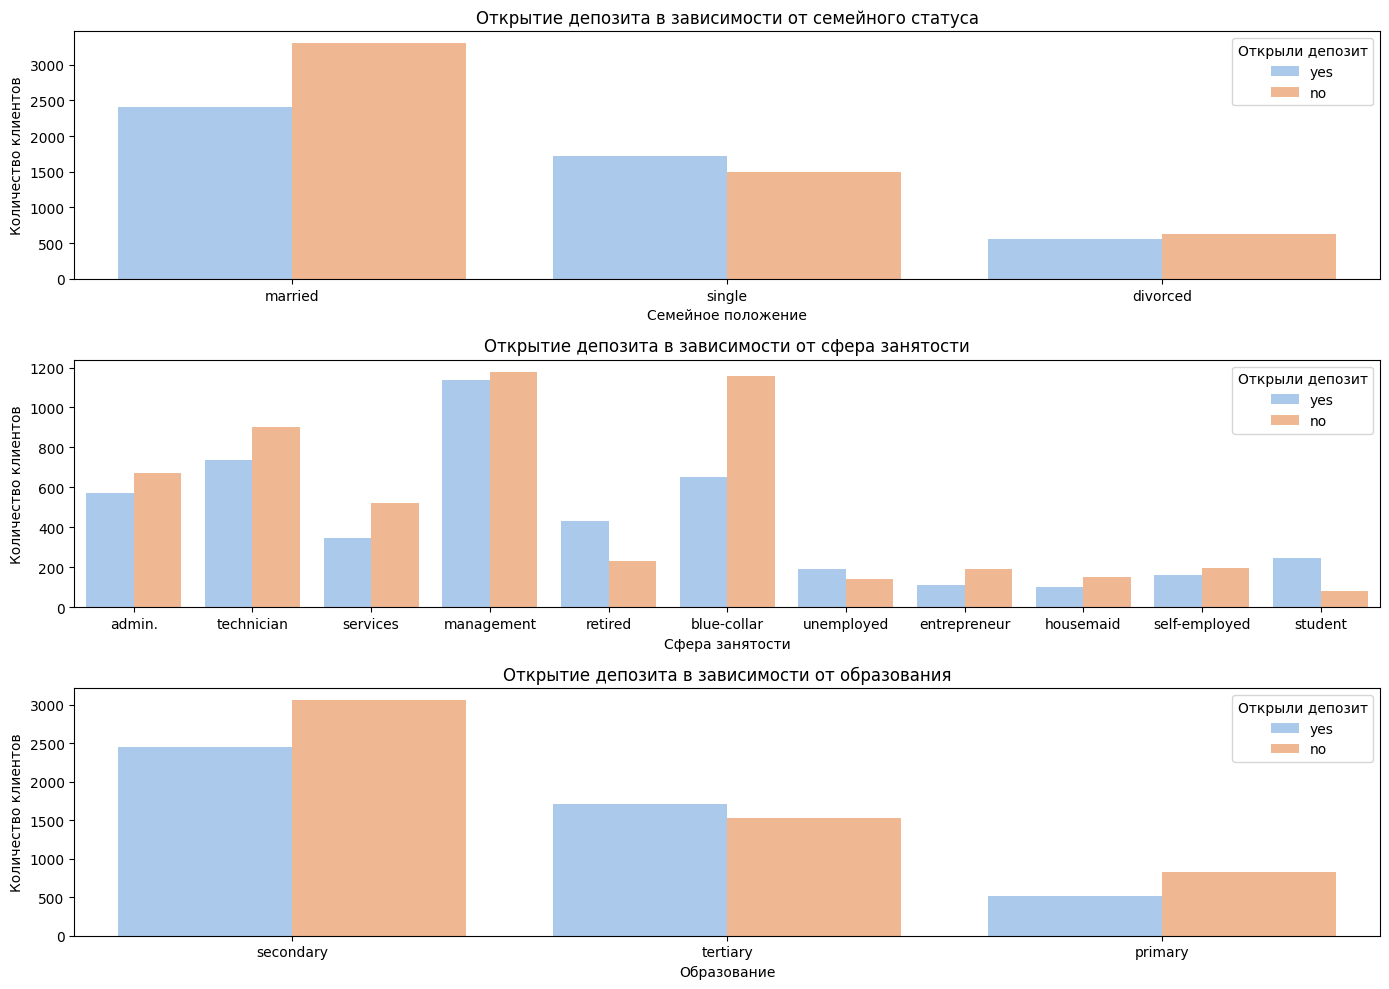

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

countplot_marital = sns.countplot(data=df_cleaned, x='marital', ax=axes[0], hue='deposit', palette='pastel')
countplot_marital.set_title('Открытие депозита в зависимости от семейного статуса')
countplot_marital.legend(title='Открыли депозит')
countplot_marital.set_ylabel('Количество клиентов')
countplot_marital.set_xlabel('Семейное положение')

countplot_job = sns.countplot(data=df_cleaned, x='job', ax=axes[1], hue='deposit', palette='pastel')
countplot_job.set_title('Открытие депозита в зависимости от сфера занятости')
countplot_job.legend(title='Открыли депозит')
countplot_job.set_ylabel('Количество клиентов')
countplot_job.set_xlabel('Сфера занятости')

countplot_education = sns.countplot(data=df_cleaned, x='education', ax=axes[2], hue='deposit', palette='pastel')
countplot_education.set_title('Открытие депозита в зависимости от образования')
countplot_education.legend(title='Открыли депозит')
countplot_education.set_ylabel('Количество клиентов')
countplot_education.set_xlabel('Образование')

plt.tight_layout()
plt.show()

**Выводы по графикам:**
- 1) Самая популярная категория *married* (состоящие в браке), но она имеет отрицательную тенденцию, как и категория *divorced* (разведенные). Единственная категория, которая имеет положительную тенденцию - это *single*(одинокие);
- 2) В целом, нет особой разницы в профессиях(в открытии депозита), в большинстве случаев это примерно равное соотношение. Но есть некоторые категории, которые привелкают внимание. Например *student* (студенты), казалось бы, не частая практика, но этому есть логичное объянение. У молодежи часто нет семьи, недвижимости за которую надо платить и так далее. И в основном за них платят родители. Вот отсюда и вытекает такая статистика. Также *retired* (на пенсии) тоже показывает положительную тенденцию в разрезе нашего целевого признака. Тут я думаю тоже довольно легко объяснить. Накопил, положил на депозит. И есть еще так называемые рабочие, именно физическая работа (*blue-collar*). Тут наоборот 2/3 - это "нет". Связано это может быть с зарплатой или географической мобильностью, надо детальнее изучить данную категорию;
- 3) На графике видно, что уровень открытия депозитов увеличивается с ростом уровня образования. Клиенты с третичным уровнем образования имеют положительную тенденцию, в то время как другие категории отрицательную.

### Профиль по образованию и семейному положению: открывшие депозит и нет

Анализ клиентов, открывших депозит:


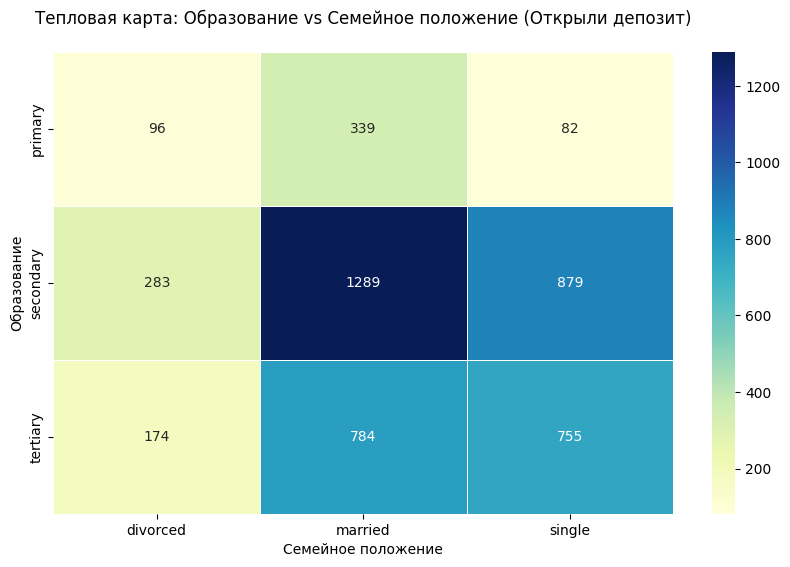


Анализ клиентов, НЕ открывших депозит:


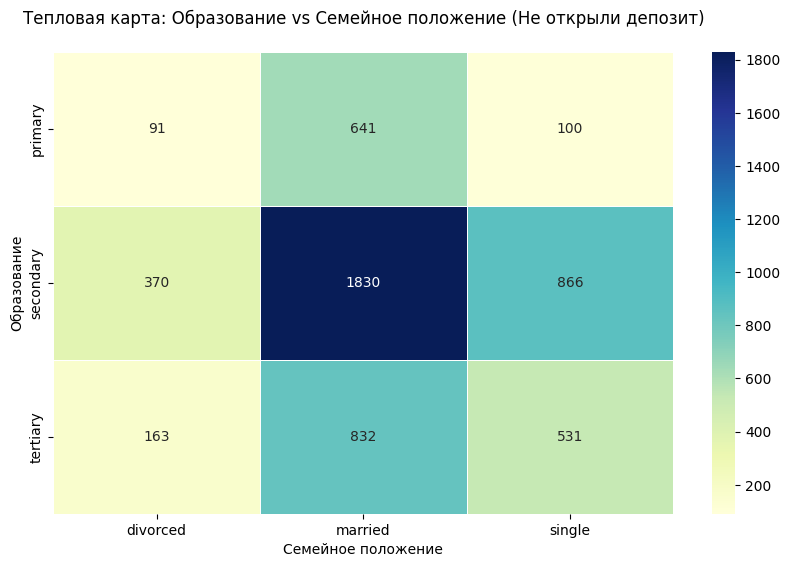


Сравнение наиболее популярных групп:
Для открывших депозит:


,Самая частая группа
marital,
divorced,secondary
married,secondary
single,secondary



Для не открывших депозит:


,Самая частая группа
marital,
divorced,secondary
married,secondary
single,secondary


In [17]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
deposit_yes = df_cleaned[df_cleaned['deposit'] == 'yes']
deposit_no = df_cleaned[df_cleaned['deposit'] == 'no']

# Создание сводных таблиц
def create_pivot_heatmap(data, title):
    """
    Функция создающая тепловую карту со сводной таблицы.

    Аргументы:
        data (DataFrame): Данные
        title (str): Название тепловой карты

    Возвращает:
        pivot: Сводная таблицы
    """
    pivot = data.pivot_table(
        values='deposit',
        columns='marital',
        index='education',
        aggfunc='count'
    )
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='g', cmap='YlGnBu', linewidths=.5)
    plt.title(title, pad=20)
    plt.xlabel('Семейное положение')
    plt.ylabel('Образование')
    plt.show()
    
    return pivot

print("Анализ клиентов, открывших депозит:")
pivot_yes = create_pivot_heatmap(deposit_yes, 
                                'Тепловая карта: Образование vs Семейное положение (Открыли депозит)')

print("\nАнализ клиентов, НЕ открывших депозит:")
pivot_no = create_pivot_heatmap(deposit_no, 
                               'Тепловая карта: Образование vs Семейное положение (Не открыли депозит)')

# Сравнение групп
print("\nСравнение наиболее популярных групп:")
print("Для открывших депозит:")
display(pivot_yes.idxmax().to_frame('Самая частая группа'))

print("\nДля не открывших депозит:")
display(pivot_no.idxmax().to_frame('Самая частая группа'))


**Выводы:** Самое популярное комбинация признаков marital и education - это married и secondary(1289 клиентов). Меньше всего клиентов с primary и single признаками

## Часть 3. Преобразование данных

### Кодирование порядковых признаков (`education`, `age_group`)

In [18]:
# преобразуйте уровни образования
le=LabelEncoder()
df_cleaned['education'] = le.fit_transform(df_cleaned['education'])
df_cleaned['age_group'] = le.fit_transform(df_cleaned['age_group'])

### Кодирование бинарных yes/no столбцов (`deposit`, `default`, `housing`, `loan`)

Все три мы будем модифицировать ровно так же: для слова yes мы возьмём в качестве значения 1, а для no — 0.

In [19]:
# преобразуйте бинарные переменные в представление из нулей и единиц
def to_binary(row):
    """
    Преобразует строковое значение в бинарный формат.

    Если значение равно 'yes', возвращает 1.
    Для всех остальных значений возвращает 0.

    Параметры:
    row (str): Строка для проверки ('yes' или другое значение).

    Возвращает:
    int: 1, если row == 'yes', иначе 0.
    """
    
    if row == 'yes':
        return 1
    else:
        return 0

# Применим функцию к бинарным столбцам
binary_cols = ['deposit', 'default', 'housing', 'loan']
for col in binary_cols:
    df_cleaned[col] = df_cleaned[col].apply(to_binary)

### One-hot кодирование номинальных признаков

In [20]:
# создайте дамми-переменные
dummies = pd.get_dummies(df_cleaned, columns=['job', 'marital', 'contact', 'month', 'poutcome'], dtype=int)
dummies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                10105 non-null  int64  
 1   education          10105 non-null  int64  
 2   default            10105 non-null  int64  
 3   balance            10105 non-null  float64
 4   housing            10105 non-null  int64  
 5   loan               10105 non-null  int64  
 6   day                10105 non-null  int64  
 7   duration           10105 non-null  int64  
 8   campaign           10105 non-null  int64  
 9   pdays              10105 non-null  int64  
 10  previous           10105 non-null  int64  
 11  deposit            10105 non-null  int64  
 12  age_group          10105 non-null  int64  
 13  job_admin.         10105 non-null  int64  
 14  job_blue-collar    10105 non-null  int64  
 15  job_entrepreneur   10105 non-null  int64  
 16  job_housemaid      10105 no

### Корреляционная матрица и проверка на мультиколлинеарность

Text(0.5, 1.0, 'Correlation matrix')

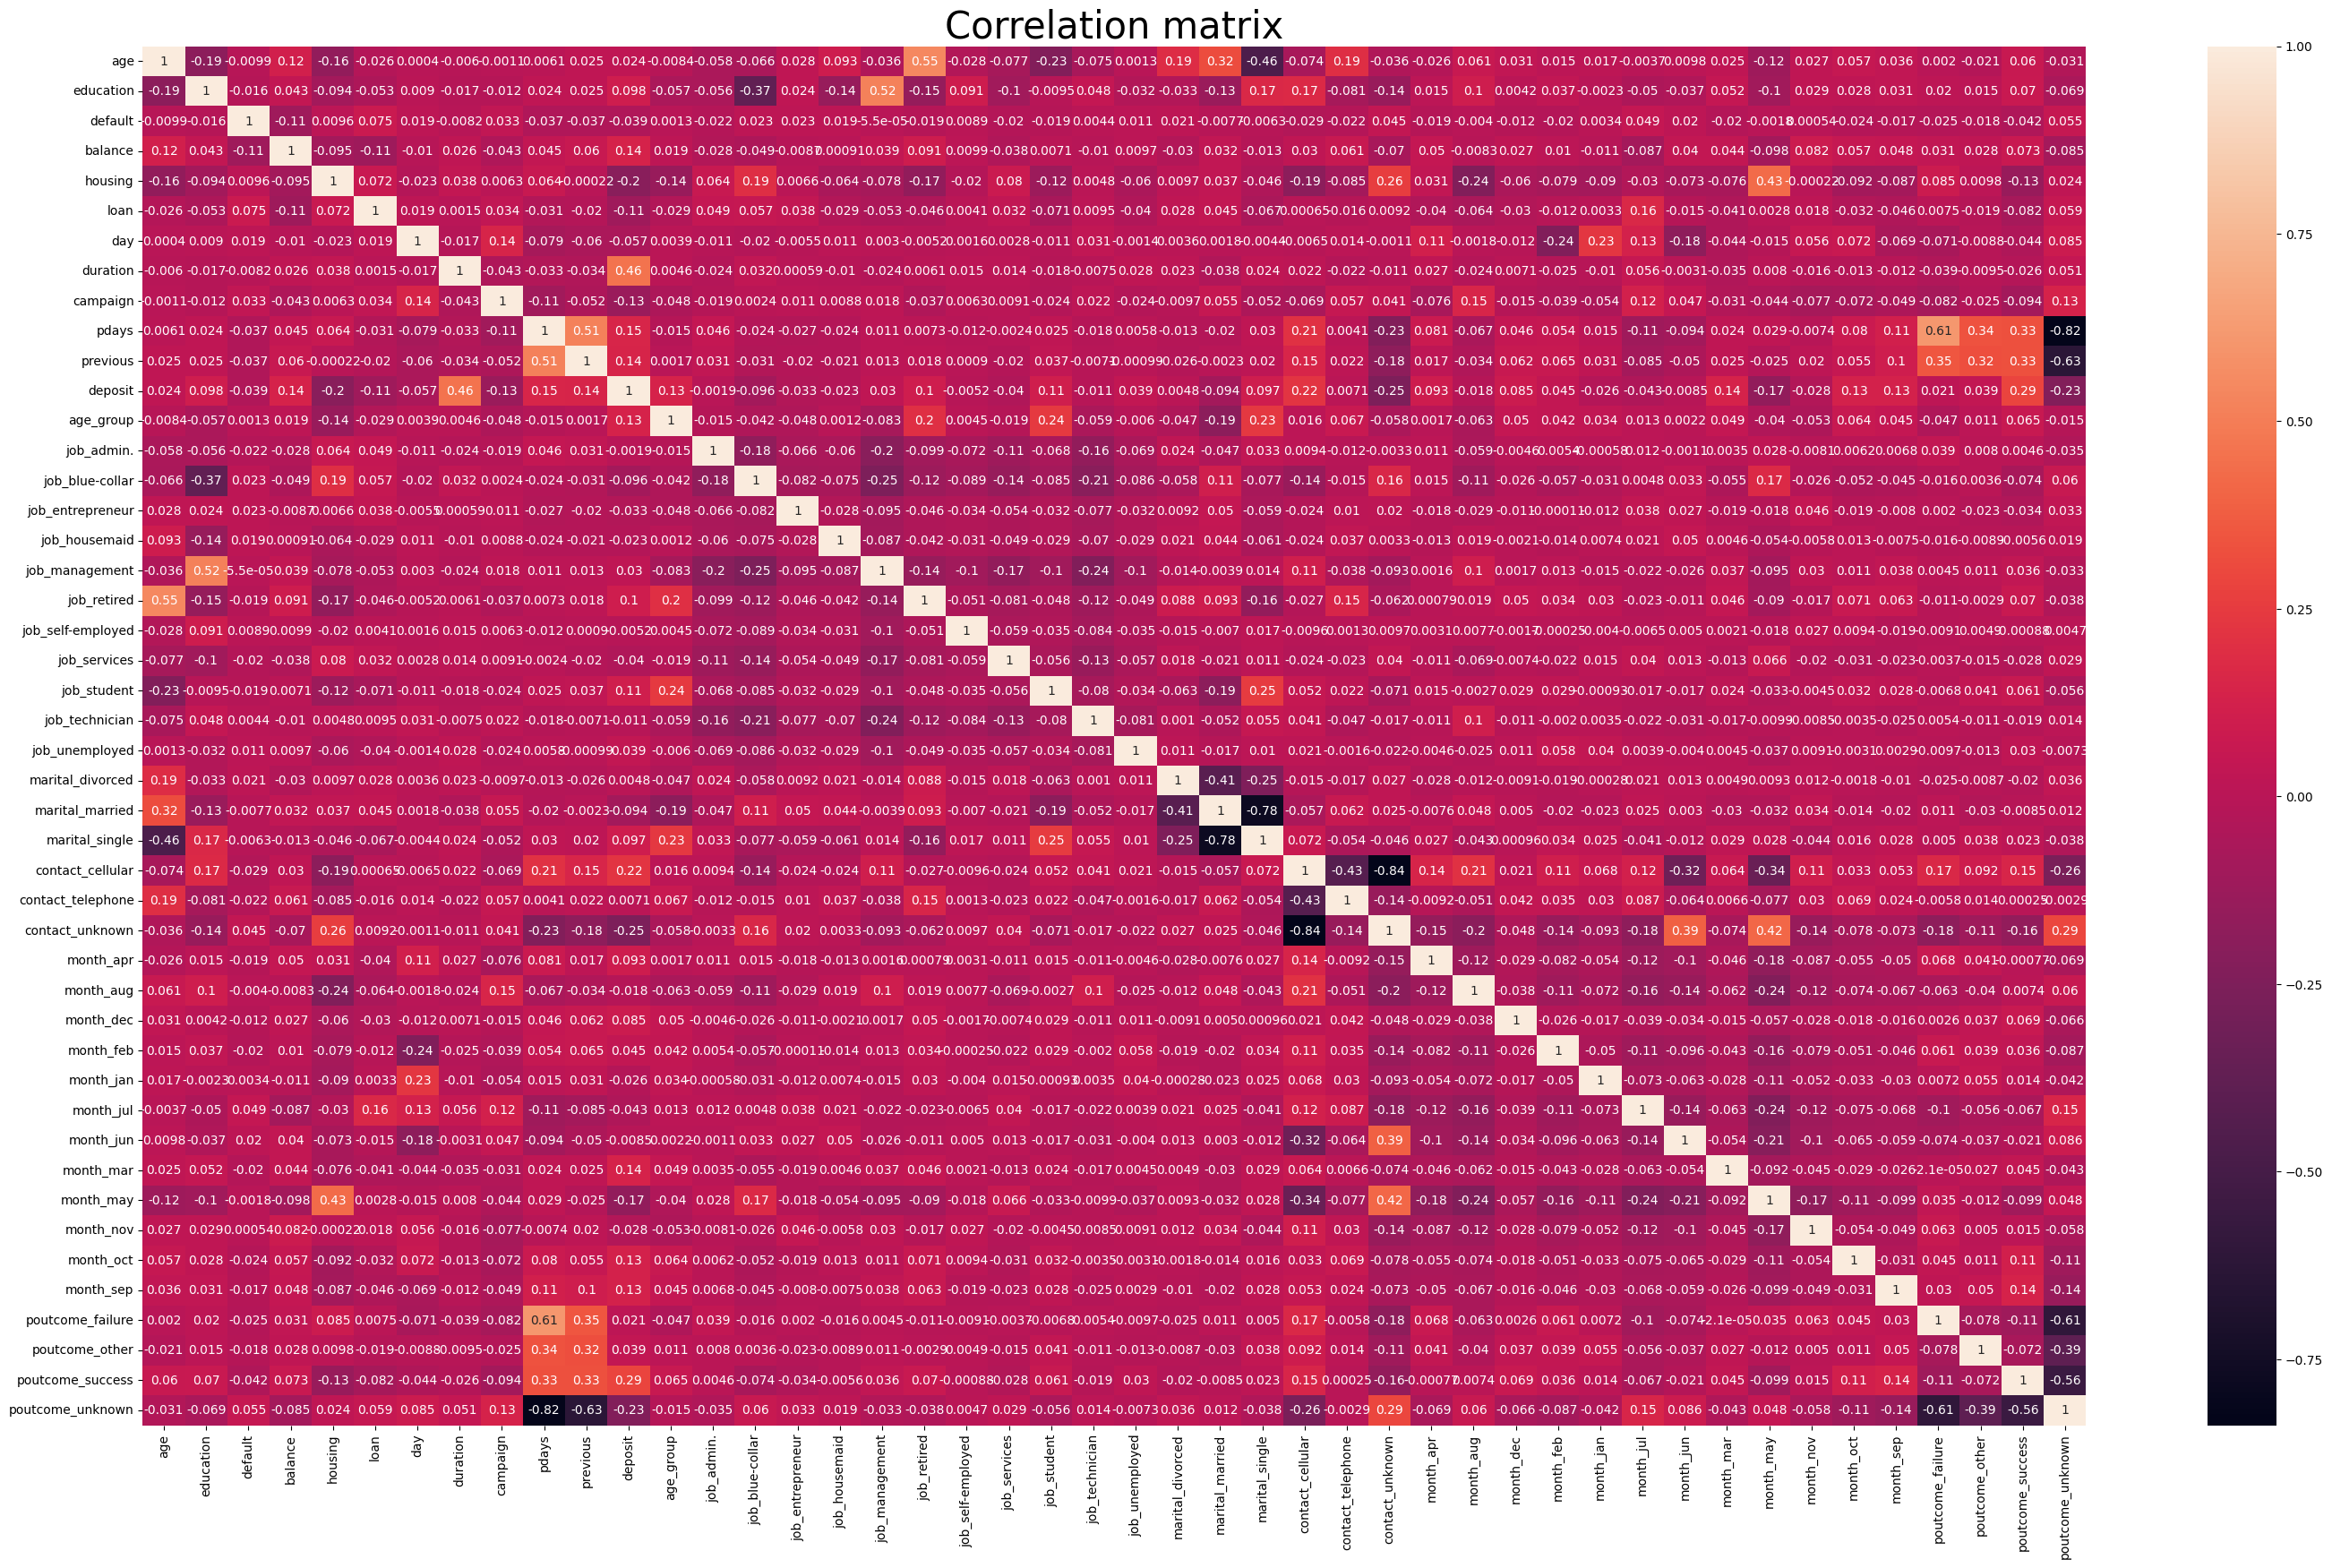

In [21]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
corr_matrix = dummies.corr()
plt.figure(figsize=(35, 20))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation matrix', fontsize=30)

### Разбиение на train/test и баланс классов на отложенной выборке

In [22]:
X = dummies.drop(['deposit'], axis=1)
y = dummies['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)
X_test.shape

(3335, 45)

In [23]:
# рассчитайте необходимые показатели
round(y_test.mean(), 2)

np.float64(0.46)

### Отбор 15 лучших признаков с помощью `SelectKBest`

In [24]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков
selector = SelectKBest(score_func=f_classif, k=15)
X_train_best = selector.fit_transform(X_train, y_train)
X_test_best = selector.transform(X_test)

selector.get_feature_names_out()

array(['balance', 'housing', 'duration', 'campaign', 'pdays', 'previous',
       'age_group', 'contact_cellular', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown'], dtype=object)

### Масштабирование признаков с помощью `MinMaxScaler`

Рассчитайте среднее арифметическое для первого предиктора (т. е. для первого столбца матрицы) из тестовой выборки. Ответ округлите до двух знаков после точки-разделителя.

In [25]:
# нормализуйте данные с помощью minmaxsxaler
scaler = preprocessing.MinMaxScaler()

scaler.fit(X_train_best)
X_train_scaled = scaler.transform(X_train_best)
X_test_scaled = scaler.transform(X_test_best)

print(round(X_test_scaled[:,0].mean(), 2))

0.47


## Часть 4. Классификация: логистическая регрессия и деревья решений

### Базовая модель: логистическая регрессия

In [26]:
# обучите логистическую регрессию и рассчитайте метрики качества
log_reg = linear_model.LogisticRegression(
    random_state=42,
    solver='sag',
    max_iter=1000
)
log_reg.fit(X_train_scaled, y_train)

y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

print(f"Accuracy на тренировочной выборке: {round(metrics.accuracy_score(y_train, y_train_pred), 2)}")
print(f"Accuracy на тестовой выборке: {round(metrics.accuracy_score(y_test, y_test_pred), 2)}")

Accuracy на тренировочной выборке: 0.82
Accuracy на тестовой выборке: 0.81


### Дерево решений

Простой алгоритм обучен. Теперь давайте обучим ещё один алгоритм — решающие деревья. В качестве параметров для начала возьмём следующие:

criterion = 'entropy';
random_state = 42.
Остальные параметры оставьте по умолчанию.

In [27]:
# обучите решающие деревья, настройте максимальную глубину
dt = tree.DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    max_depth=6
)

dt.fit(X_train_scaled, y_train)

y_train_pred = dt.predict(X_train_scaled)
y_test_pred = dt.predict(X_test_scaled)

print(f"Accuracy на тренировочной выборке: {round(metrics.accuracy_score(y_train, y_train_pred), 2)}")
print(f"Accuracy на тестовой выборке: {round(metrics.accuracy_score(y_test, y_test_pred), 2)}")

Accuracy на тренировочной выборке: 0.82
Accuracy на тестовой выборке: 0.81


### Подбор гиперпараметров дерева решений с помощью `GridSearchCV`

In [28]:
# подберите оптимальные параметры с помощью gridsearch
from sklearn.model_selection import GridSearchCV

param_grid = {'min_samples_split': [2, 5, 7, 10],
              'max_depth':[3,5,7]}

grid_search = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(random_state=42),
    param_grid=param_grid, 
    cv=3, 
    scoring=('f1'),
    return_train_score=True
)

%time grid_search.fit(X_train_scaled, y_train) 
print("accuracy на тестовом наборе: {:.2f}".format(grid_search.score(X_test_scaled, y_test)))
y_test_pred = grid_search.predict(X_test_scaled)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search.best_params_))

CPU times: total: 1.39 s
Wall time: 1.73 s
accuracy на тестовом наборе: 0.80
f1_score на тестовом наборе: 0.80
Наилучшие значения гиперпараметров: {'max_depth': 7, 'min_samples_split': 2}


## Часть 5. Классификация: ансамблевые модели и важность признаков

### Случайный лес

In [29]:
# обучите на ваших данных случайный лес
rf = ensemble.RandomForestClassifier(
    n_estimators=1000,
    criterion='gini',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

y_train_pred = rf.predict(X_train_scaled)
y_test_pred = rf.predict(X_test_scaled)

print(f'Показание метрик для тестовой выборки: \n {metrics.classification_report(y_test, y_test_pred)}')

Показание метрик для тестовой выборки: 
               precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Градиентный бустинг

In [30]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
from sklearn.ensemble import GradientBoostingClassifier

# Создаем объект класса градиентный бустинг
gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

y_train_pred = gb.predict(X_train_scaled)
y_test_pred = gb.predict(X_test_scaled)

print(f'Показание метрики F1 для тестовой выборки: {round(metrics.f1_score(y_test, y_test_pred),2)}')

Показание метрики F1 для тестовой выборки: 0.82


### Стекинг (логистическая регрессия + случайный лес + градиентный бустинг)

In [31]:
# объедините уже известные вам алгоритмы с помощью стекинга
estimators = [
    ('log_reg', linear_model.LogisticRegression(
        random_state=42,
        solver='sag',
        max_iter=1000
    )),
    ('rf', ensemble.RandomForestClassifier(
        n_estimators=1000,
        criterion='gini',
        min_samples_leaf=5,
        max_depth=10,
        random_state=42
    )),
    ('gb', GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=300,
        min_samples_leaf=5,
        max_depth=5,
        random_state=42
    ))
]

# Создаем объект класса стекинг
reg = StackingClassifier(
    estimators=estimators,
    final_estimator=linear_model.LogisticRegression(
        random_state=42,
        solver='sag',
        max_iter=1000)
    )

reg.fit(X_train_scaled, y_train)
y_pred_stack = reg.predict(X_test_scaled)

print(f'Показание метрики precision для тестовой выборки: {round(metrics.precision_score(y_test, y_pred_stack), 2)}')

Показание метрики precision для тестовой выборки: 0.81


### Важность признаков по модели градиентного бустинга

             Признак  Важность
2           duration  0.507106
13  poutcome_success  0.114958
8    contact_unknown  0.072622
0            balance  0.057952
4              pdays  0.055155
1            housing  0.047725
6          age_group  0.039902
9          month_mar  0.027819
11         month_oct  0.019880
10         month_may  0.015214
3           campaign  0.014777
12         month_sep  0.013530
5           previous  0.008269
7   contact_cellular  0.003580
14  poutcome_unknown  0.001509


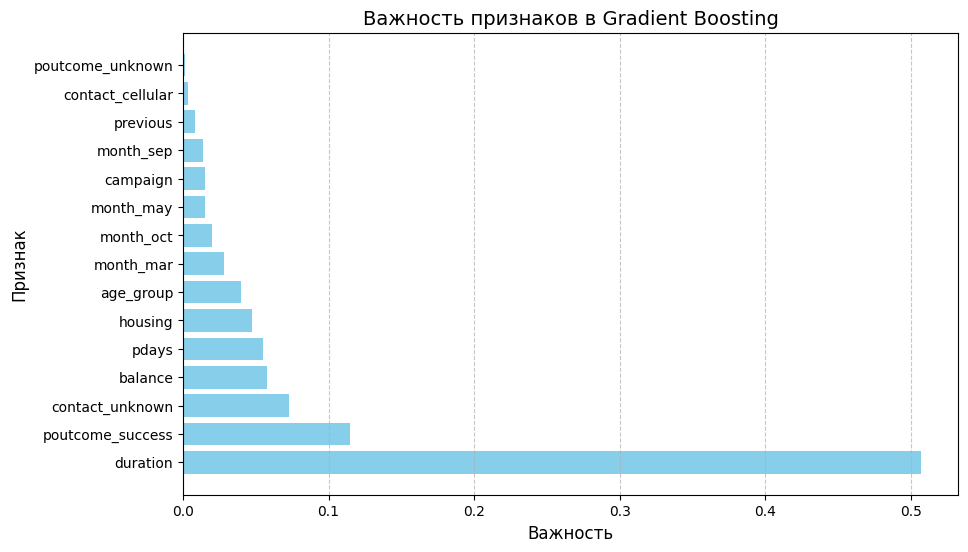

In [32]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга
feature_importance = gb.feature_importances_
feature_names = selector.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': feature_importance
}).sort_values('Важность', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Признак'], feature_importance_df['Важность'], color='skyblue')
plt.title('Важность признаков в Gradient Boosting', fontsize=14)
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Выводы:**
- Самый важный признак → duration (0.507).
Вероятно, чем дольше контакт с клиентом, тем выше шанс успеха.

- Второй по важности → poutcome_success (0.115).
Успешный предыдущий контакт сильно влияет на результат.

- Наименее важные → poutcome_unknown (0.0015) и contact_cellular (0.0036).
Возможно, их можно исключить из модели без потери качества.

### Оптимизация гиперпараметров с помощью Optuna (случайный лес)

In [33]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
import optuna

def optuna_rf(trial):
  n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
  max_depth = trial.suggest_int('max_depth', 10, 30, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

  model = ensemble.RandomForestClassifier(n_estimators=n_estimators,
                                          max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf,
                                          random_state=42)
  model.fit(X_train_scaled, y_train)
  score = metrics.f1_score(y_train, model.predict(X_train_scaled))

  return score

study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
study.optimize(optuna_rf, n_trials=20)

print("Наилучшие значения гиперпараметров {}".format(study.best_params))
print("f1_score на обучающем наборе: {:.2f}".format(study.best_value))

model = ensemble.RandomForestClassifier(**study.best_params,random_state=42, )
model.fit(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)
print("accuracy на тестовом наборе: {:.2f}".format(model.score(X_test_scaled, y_test)))
y_test_pred = model.predict(X_test_scaled)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

[I 2026-08-24 19:08:04,895] A new study created in memory with name: RandomForestClassifier


[I 2026-08-24 19:08:06,581] Trial 0 finished with value: 0.8747645951035782 and parameters: {'n_estimators': 107, 'max_depth': 12, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.8747645951035782.


[I 2026-08-24 19:08:08,900] Trial 1 finished with value: 0.8655226209048362 and parameters: {'n_estimators': 161, 'max_depth': 16, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8747645951035782.


[I 2026-08-24 19:08:10,701] Trial 2 finished with value: 0.8492935635792779 and parameters: {'n_estimators': 154, 'max_depth': 11, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.8747645951035782.


[I 2026-08-24 19:08:13,037] Trial 3 finished with value: 0.8576761549230051 and parameters: {'n_estimators': 200, 'max_depth': 27, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.8747645951035782.


...

[I 2026-08-24 19:09:05,150] Trial 18 finished with value: 0.9235368156073002 and parameters: {'n_estimators': 164, 'max_depth': 30, 'min_samples_leaf': 2}. Best is trial 15 with value: 0.9246231155778895.


[I 2026-08-24 19:09:08,305] Trial 19 finished with value: 0.8927119174225837 and parameters: {'n_estimators': 146, 'max_depth': 30, 'min_samples_leaf': 3}. Best is trial 15 with value: 0.9246231155778895.


Наилучшие значения гиперпараметров {'n_estimators': 176, 'max_depth': 25, 'min_samples_leaf': 2}
f1_score на обучающем наборе: 0.92


accuracy на тестовом наборе: 0.83


f1_score на тестовом наборе: 0.82
